# 06 · Hybrid Event Reconstruction — Copulas, K-means and MaxDiss

**Author:** Salvador Navas  
**Basin:** Río Besaya — Los Corrales de Buelna, Cantabria

## Methodological workflow

```
Observed Q series
      │
      ▼
FloodEventSelector
  ├─ extract_events()      → events (Qmax, Qmed, Duration)
  ├─ classify_events()     → K-means clustering by hydrograph type
  ├─ fit_marginals()       → GEV / lognorm / gamma per variable
  ├─ fit_copula()          → Gaussian copula (Pearson correlation)
  └─ generate_synthetic()  → 5 000 synthetic events
         │
         ▼
HydrographReconstructor
  ├─ select_representatives() → MaxDiss: N most dissimilar centroids
  └─ build_hydrographs()      → Quadratic scaling Q_synt = a·Q² + b·Q
         │
         ▼
  425 hydrographs for HEC-RAS  →  Notebook 07
```

**Pre-computed data available** (loaded directly if present):
- `processed/eventos_maxdiss.csv` — events selected after MaxDiss
- `processed/matriz_sintetica_maxdiss.csv` — classified synthetic events
- `processed/hydrographs_maxdiss/Hidrograma_*.csv` — 425 reconstructed hydrographs


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from pyhydra.climate.hybrid_downscaling import FloodEventSelector
from pyhydra.climate.hybrid_downscaling.reconstruction import HydrographReconstructor

# Resolve repo root: Jupyter sets cwd to the notebook dir;
# in Docker/script contexts cwd=/workspace (one level up)
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent.parent.parent if _cwd.name == 'los_corrales_buelna' else _cwd
DATA_ROOT = REPO_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR  = DATA_ROOT / 'processed'

HYDRO_MAXDISS    = PROC_DIR / 'hydrographs_maxdiss'
EVENTOS_MAXDISS  = PROC_DIR / 'eventos_maxdiss.csv'
MATRIZ_SINTETICA = PROC_DIR / 'matriz_sintetica_maxdiss.csv'
EVENTOS_OBS      = PROC_DIR / 'eventos_observados.csv'

N_SYNTHETIC   = 5000
N_MAXDISS     = 425
Q_THRESHOLD   = 30.0   # m³/s — umbral de separación de eventos (threshold crossing)
Q_THRESHOLD2  = None   # m³/s — umbral2: pico mínimo para retener el evento (None = Q_THRESHOLD)
N_CLUSTERS    = 3      # tipos de hidrograma K-means
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200, 500]

print('Rutas OK')
print(f'  eventos_maxdiss     : {EVENTOS_MAXDISS.exists()}')
print(f'  matriz_sintetica    : {MATRIZ_SINTETICA.exists()}')
print(f'  hydrographs_maxdiss : {HYDRO_MAXDISS.exists()}')
if HYDRO_MAXDISS.exists():
    n_hydro = len(list(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv')))
    print(f'    → {n_hydro} hidrogramas encontrados')

Rutas OK
  eventos_maxdiss     : True
  matriz_sintetica    : True
  hydrographs_maxdiss : True
    → 425 hidrogramas encontrados


## 1. Load observed streamflow series

Estación seleccionada : 1937
Período               : 1970-10-01 → 2000-09-30
N días con datos      : 10957
Qmax = 1005.0 m³/s  |  Qmedio = 12.45 m³/s


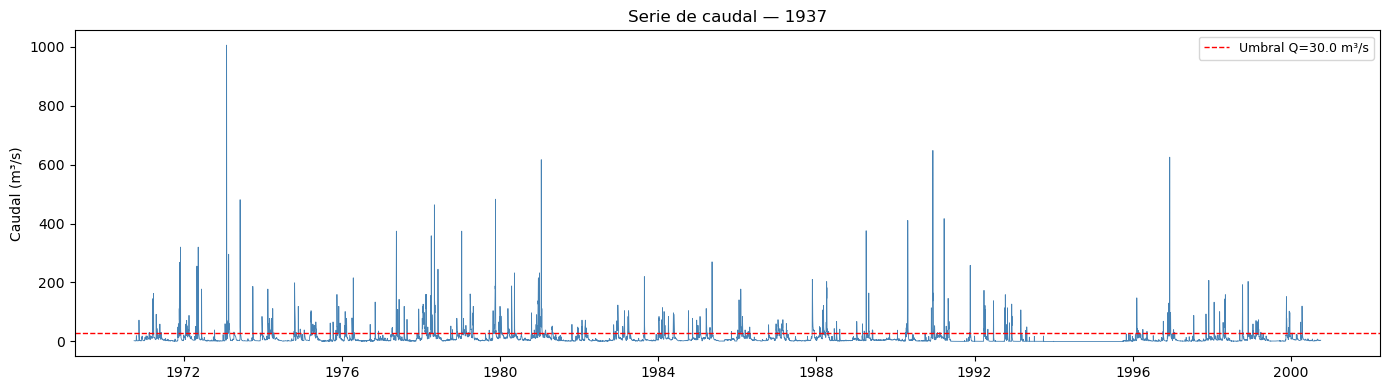

In [2]:
flow = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)

# Use the station with the longest record (Torrelavega or Las Caldas)
q_col = flow.columns[flow.count().argmax()]
Q_obs = flow[q_col].dropna()
Q_obs.name = 'Q_obs'

print(f'Estación seleccionada : {q_col}')
print(f'Período               : {Q_obs.index[0].date()} → {Q_obs.index[-1].date()}')
print(f'N días con datos      : {len(Q_obs)}')
print(f'Qmax = {Q_obs.max():.1f} m³/s  |  Qmedio = {Q_obs.mean():.2f} m³/s')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(Q_obs.index, Q_obs.values, lw=0.6, color='steelblue')
ax.axhline(Q_THRESHOLD, color='red', lw=1, ls='--', label=f'Umbral Q={Q_THRESHOLD} m³/s')
ax.set(ylabel='Caudal (m³/s)', title=f'Serie de caudal — {q_col}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR / 'serie_caudal.png', dpi=150)
plt.show()

## 2. Observed events — separation and characterisation

Independent events are extracted from the streamflow series using a separation
threshold. Each event is characterised by three variables:

- **Qmax** — peak flow (m³/s)
- **Qmed** — mean flow during the event (m³/s)
- **Duration** — total event duration (days)


Eventos observados cargados desde CSV: 224
       Inicio_evento  Fin_evento    Qmax    Qmed  Duracion  Tipo_Hidro
count         224.00      224.00  224.00  224.00    224.00      224.00
mean         5541.93     5701.02  214.77   22.84    159.09        2.05
std          2933.87     2978.98  158.73   16.32    163.23        1.31
min            39.00       45.00   30.90    1.28      1.00        0.00
25%          3058.75     3311.00  104.34   10.59     55.75        0.00
50%          5213.50     5425.50  159.33   17.97    114.00        3.00
75%          7854.75     8045.75  258.24   30.83    233.75        3.00
max         10782.00    10784.00  647.82  100.66   1157.00        3.00


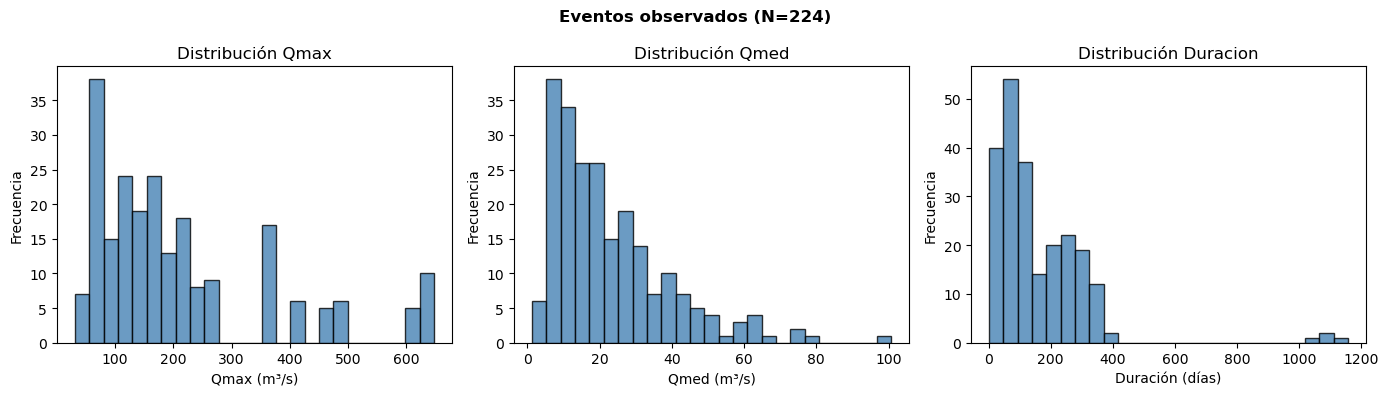

In [3]:
_needs_recompute = not EVENTOS_OBS.exists()
if EVENTOS_OBS.exists():
    eventos_obs = pd.read_csv(EVENTOS_OBS)
    _has_tipo = 'shape_type' in eventos_obs.columns or 'Tipo_Hidro' in eventos_obs.columns
    if not _has_tipo:
        print('CSV stale (falta shape_type) — recalculando clasificación...')
        EVENTOS_OBS.unlink()
        _needs_recompute = True
    else:
        print(f'Eventos observados cargados desde CSV: {len(eventos_obs)}')

if _needs_recompute:
    # Extract and characterise flood events via threshold crossing
    # API: FloodEventSelector(discharge, threshold, threshold2=None, n_types=25, n_synthetic=5000)
    selector_tmp = FloodEventSelector(
        discharge  = Q_obs,
        threshold  = Q_THRESHOLD,
        threshold2 = Q_THRESHOLD2,
        n_types    = N_CLUSTERS,
        n_synthetic= N_SYNTHETIC,
    )
    selector_tmp.extract_events()
    eventos_obs = selector_tmp.classify_events()   # → Qmax, Qmed, Duracion, shape_type
    eventos_obs.to_csv(EVENTOS_OBS, index=False)
    print(f'Eventos extraídos y exportados: {len(eventos_obs)}')

# Normalise column names: shape_type → Tipo_Hidro
if 'Tipo_Hidro' not in eventos_obs.columns and 'shape_type' in eventos_obs.columns:
    eventos_obs = eventos_obs.rename(columns={'shape_type': 'Tipo_Hidro'})

print(eventos_obs.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
                           ['Qmax', 'Qmed', 'Duracion'],
                           ['Qmax (m³/s)', 'Qmed (m³/s)', 'Duración (días)']):
    if col in eventos_obs.columns:
        ax.hist(eventos_obs[col], bins=25, color='steelblue', edgecolor='k', alpha=0.8)
        ax.set(xlabel=label, ylabel='Frecuencia', title=f'Distribución {col}')
plt.suptitle(f'Eventos observados (N={len(eventos_obs)})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'histogramas_eventos_obs.png', dpi=150)
plt.show()

## 3. Hydrograph type classification — K-means

Events are classified into **N_CLUSTERS types** by K-means clustering on the
normalised variables (Qmax, Qmed, Duration). Each cluster represents a type of
hydrological basin response (e.g., fast event / prolonged event / mixed event).


In [4]:
if MATRIZ_SINTETICA.exists() and EVENTOS_MAXDISS.exists():
    # Load pre-computed results
    synthetic = pd.read_csv(MATRIZ_SINTETICA, index_col=0)
    if 'Tipo_Hidro' not in synthetic.columns and 'shape_type' in synthetic.columns:
        synthetic = synthetic.rename(columns={'shape_type': 'Tipo_Hidro'})
    eventos_maxdiss = pd.read_csv(EVENTOS_MAXDISS, index_col=0)

    n_tipos = synthetic['Tipo_Hidro'].nunique() if 'Tipo_Hidro' in synthetic.columns else N_CLUSTERS
    print(f'Datos pre-computados cargados:')
    print(f'  Eventos sintéticos: {len(synthetic)}')
    print(f'  Eventos MaxDiss   : {len(eventos_maxdiss)}')
    print(f'  Tipos K-means     : {n_tipos}')

    selector = None  # no es necesario recalcular

else:
    # Run full pipeline:
    #   threshold crossing → PCA+K-means classification → marginal fitting
    #   → Gaussian copula → N_SYNTHETIC synthetic events
    print('Ejecutando FloodEventSelector (cópula gaussiana + K-means)...')
    selector = FloodEventSelector(
        discharge  = Q_obs,
        threshold  = Q_THRESHOLD,
        threshold2 = Q_THRESHOLD2,   # umbral2: pico mínimo para retener evento
        n_types    = N_CLUSTERS,     # K en K-means (tipos de hidrograma)
        n_synthetic= N_SYNTHETIC,
        output_dir = PROC_DIR,
    )
    selector.extract_events()
    selector.classify_events()     # PCA + K-means → shape_type
    selector.fit_marginals()       # GEV / lognorm / gamma por variable
    selector.fit_copula()          # Gaussian copula
    synthetic = selector.generate_synthetic(seed=42)   # n_synthetic set at construction

    # Normalise column name for downstream cells
    if 'Tipo_Hidro' not in synthetic.columns and 'shape_type' in synthetic.columns:
        synthetic = synthetic.rename(columns={'shape_type': 'Tipo_Hidro'})

    synthetic.to_csv(MATRIZ_SINTETICA)
    eventos_maxdiss = synthetic  # placeholder; MaxDiss selection happens in Section 5
    print(f'Eventos sintéticos generados: {len(synthetic)}')

Datos pre-computados cargados:
  Eventos sintéticos: 4943
  Eventos MaxDiss   : 425
  Tipos K-means     : 25


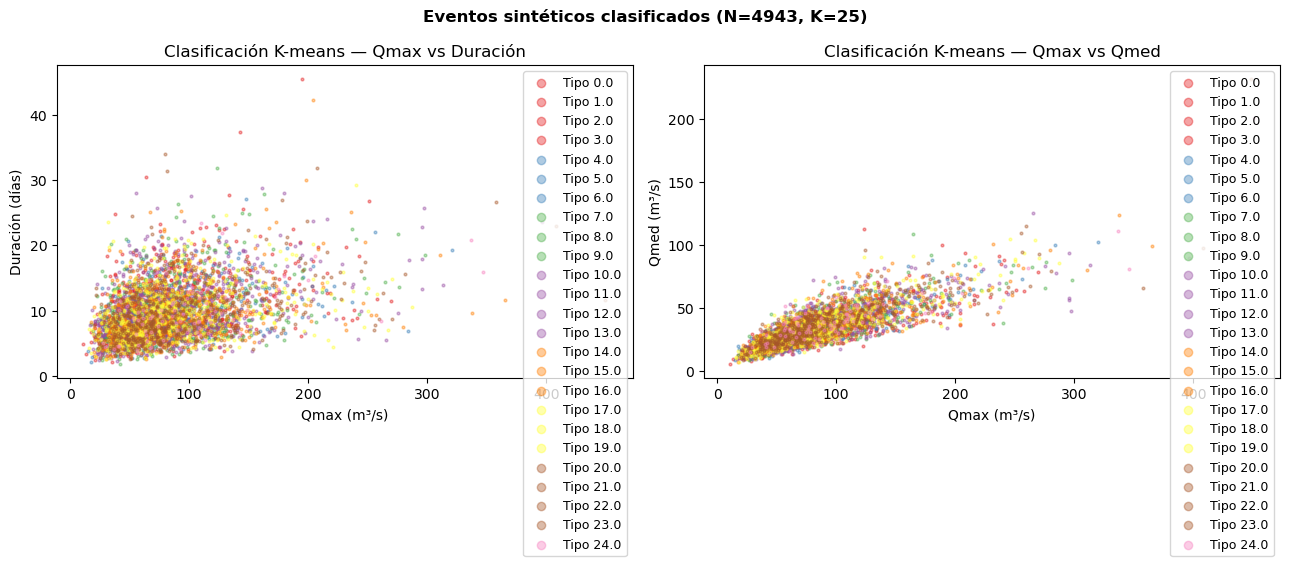

Distribución de eventos por tipo:
Tipo_Hidro
0.0      66
1.0     388
2.0     216
3.0     273
4.0      79
5.0     283
6.0      51
7.0     294
8.0     295
9.0     100
10.0    359
11.0    467
12.0     99
13.0     42
14.0    322
15.0    143
16.0    142
17.0    225
18.0    342
19.0     98
20.0    181
21.0    235
22.0    134
23.0     21
24.0     88
Name: count, dtype: int64


In [5]:
# Visualisation de los clústeres K-means
if 'Tipo_Hidro' in synthetic.columns and 'Qmax' in synthetic.columns:
    tipos = sorted(synthetic['Tipo_Hidro'].unique())
    colors_k = cm.Set1(np.linspace(0, 0.8, len(tipos)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Qmax vs Duration
    for tipo, c in zip(tipos, colors_k):
        sub = synthetic[synthetic['Tipo_Hidro'] == tipo]
        axes[0].scatter(sub['Qmax'], sub.get('Duracion', sub.get('duration', np.nan)),
                        s=4, alpha=0.4, color=c, label=f'Tipo {tipo}')
    axes[0].set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
                title='Clasificación K-means — Qmax vs Duración')
    axes[0].legend(markerscale=3, fontsize=9)

    # Qmax vs Qmed
    for tipo, c in zip(tipos, colors_k):
        sub = synthetic[synthetic['Tipo_Hidro'] == tipo]
        axes[1].scatter(sub['Qmax'], sub.get('Qmed', sub.get('mean_flow', np.nan)),
                        s=4, alpha=0.4, color=c, label=f'Tipo {tipo}')
    axes[1].set(xlabel='Qmax (m³/s)', ylabel='Qmed (m³/s)',
                title='Clasificación K-means — Qmax vs Qmed')
    axes[1].legend(markerscale=3, fontsize=9)

    plt.suptitle(f'Eventos sintéticos clasificados (N={len(synthetic)}, K={len(tipos)})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'kmeans_clusters.png', dpi=150)
    plt.show()

    # Conteo por tipo
    print('Distribución de eventos por tipo:')
    print(synthetic['Tipo_Hidro'].value_counts().sort_index())
else:
    print('Columna Tipo_Hidro no disponible — revisar formato de matriz_sintetica_maxdiss.csv')
    print('Columnas disponibles:', list(synthetic.columns))

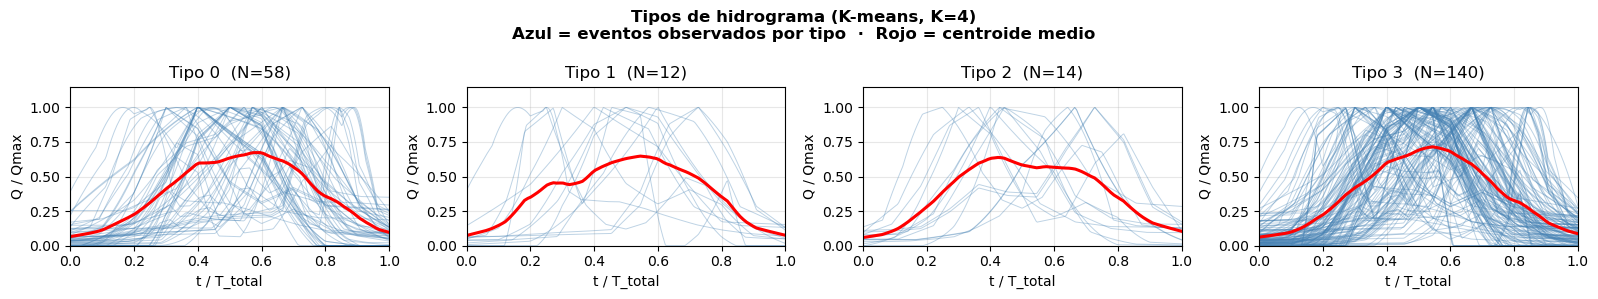

Grid de tipos guardado: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/kmeans_hydro_types.png


In [6]:
# --- Plot 3a: Hydrograph type grid ---
# Each panel: all observed events of that K-means cluster (blue) + centroid (red)
HYDRO_OBS_DIR = PROC_DIR / 'hydrographs'

if HYDRO_OBS_DIR.exists() and 'Tipo_Hidro' in eventos_obs.columns:
    obs_files = sorted(HYDRO_OBS_DIR.glob('Hidrograma_[0-9]*.csv'),
                       key=lambda f: int(f.stem.split('_')[1]))

    # Load all observed hydrographs; normalise time and Q to [0,1]
    obs_hydros = {}
    for hf in obs_files:
        j = int(hf.stem.split('_')[1])
        try:
            df = pd.read_csv(hf, index_col=0)
            t  = df.index.astype(float)
            Q  = df.iloc[:, 0].values.astype(float)
            t_n = (t - t[0]) / (t[-1] - t[0]) if t[-1] > t[0] else np.zeros_like(t)
            q_n = Q / Q.max() if Q.max() > 0 else Q
            obs_hydros[j] = (t_n, q_n)
        except Exception:
            pass

    tipos = sorted(eventos_obs['Tipo_Hidro'].unique())
    n_tipos = len(tipos)
    ncols   = min(5, n_tipos)
    nrows   = int(np.ceil(n_tipos / ncols))

    t_grid = np.linspace(0, 1, 100)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes_flat = np.array(axes).ravel() if n_tipos > 1 else [axes]

    for ax, tipo in zip(axes_flat, tipos):
        mask    = eventos_obs['Tipo_Hidro'] == tipo
        indices = eventos_obs.index[mask].tolist()

        q_stack = []
        for j in indices:
            if j in obs_hydros:
                t_n, q_n = obs_hydros[j]
                ax.plot(t_n, q_n, lw=0.7, color='steelblue', alpha=0.35)
                if len(t_n) > 1:
                    q_stack.append(np.interp(t_grid, t_n, q_n))

        # Mean centroid in red
        if q_stack:
            ax.plot(t_grid, np.mean(q_stack, axis=0), lw=2.2, color='red', label='Centroide')

        ax.set(title=f'Tipo {int(tipo)}  (N={mask.sum()})',
               xlabel='t / T_total', ylabel='Q / Qmax')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.15)
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[n_tipos:]:
        ax.set_visible(False)

    plt.suptitle(f'Tipos de hidrograma (K-means, K={n_tipos})\n'
                 f'Azul = eventos observados por tipo  ·  Rojo = centroide medio',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'kmeans_hydro_types.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Grid de tipos guardado: {PROC_DIR}/kmeans_hydro_types.png')
else:
    missing = []
    if not HYDRO_OBS_DIR.exists():
        missing.append(f'directorio {HYDRO_OBS_DIR}')
    if 'Tipo_Hidro' not in eventos_obs.columns:
        missing.append('columna Tipo_Hidro en eventos_obs')
    print(f'⚠  No se puede mostrar grid de tipos: faltan {", ".join(missing)}')

## 4. Gaussian copula — fitting and synthetic sample

The Gaussian copula is fitted in the normal-score space (normal score transform)
of each variable. The Pearson correlation in that space defines the dependence
between Qmax, Qmed and Duration.

The 5 000 synthetic events are generated by sampling the copula and applying the
inverse transform through the fitted marginal distributions (GEV, lognormal, gamma, …).


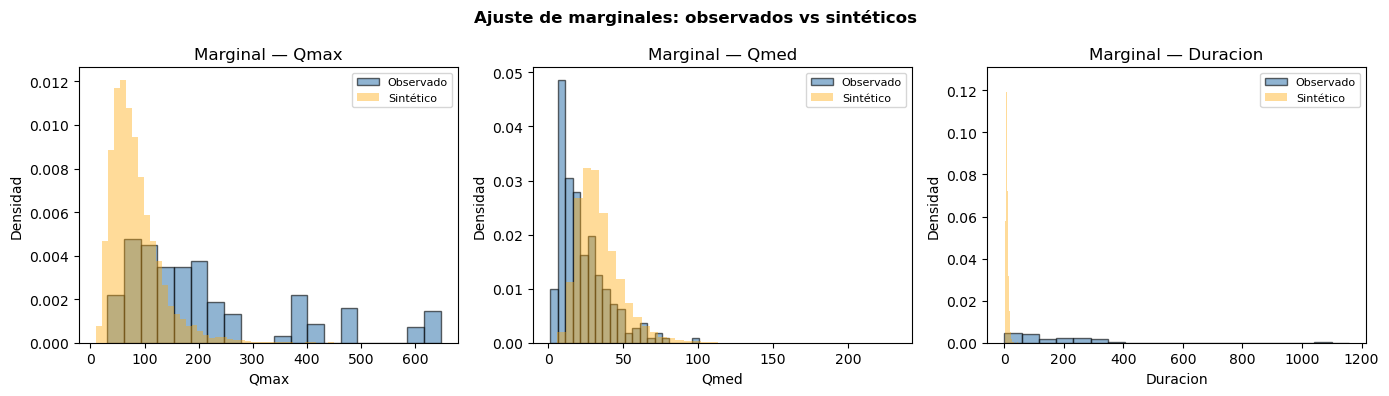

In [7]:
# Compare marginal distribution: observed vs synthetic
obs_cols = {'Qmax': 'Qmax', 'Qmed': 'Qmed', 'Duracion': 'Duracion'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (var, col) in zip(axes, obs_cols.items()):
    if col in eventos_obs.columns and col in synthetic.columns:
        ax.hist(eventos_obs[col].dropna(), bins=20, density=True,
                alpha=0.6, color='steelblue', label='Observado', edgecolor='k')
        ax.hist(synthetic[col].dropna(),    bins=40, density=True,
                alpha=0.4, color='orange',   label='Sintético', edgecolor='none')
        ax.set(xlabel=col, ylabel='Densidad', title=f'Marginal — {col}')
        ax.legend(fontsize=8)
    else:
        ax.set_title(f'{col} — no disponible')
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Ajuste de marginales: observados vs sintéticos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'copula_marginals.png', dpi=150)
plt.show()

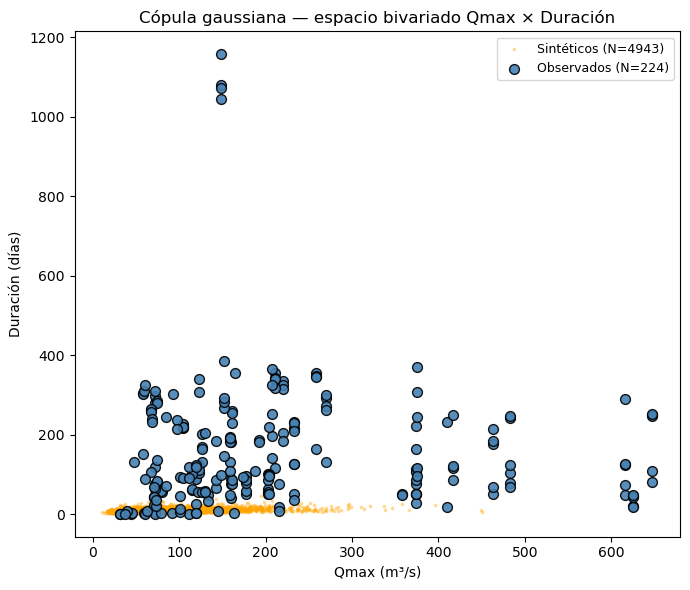

In [8]:
# Bivariate scatter plot: observed (large points) over synthetic cloud
fig, ax = plt.subplots(figsize=(7, 6))

if 'Qmax' in synthetic.columns and 'Duracion' in synthetic.columns:
    ax.scatter(synthetic['Qmax'], synthetic['Duracion'],
               s=3, alpha=0.3, color='orange', label=f'Sintéticos (N={len(synthetic)})')
if 'Qmax' in eventos_obs.columns and 'Duracion' in eventos_obs.columns:
    ax.scatter(eventos_obs['Qmax'], eventos_obs['Duracion'],
               s=50, alpha=0.9, color='steelblue', edgecolors='k', zorder=5,
               label=f'Observados (N={len(eventos_obs)})')

ax.set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
       title='Cópula gaussiana — espacio bivariado Qmax × Duración')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR / 'copula_scatter.png', dpi=150)
plt.show()

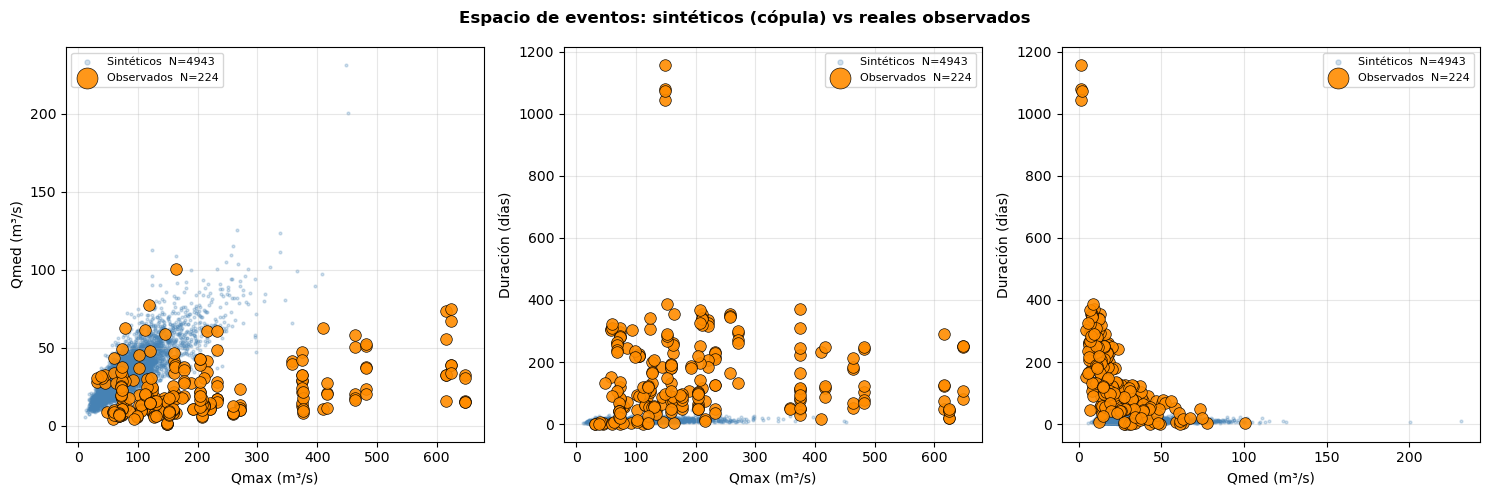

In [9]:
# --- Plot 3b: Synthetic vs Real observed — 3-panel scatter ---
# Blue dots = 5 000 synthetic events from copula
# Orange circles = real observed events
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

_pairs = [
    ('Qmax',    'Qmed',    'Qmax (m³/s)',    'Qmed (m³/s)'),
    ('Qmax',    'Duracion','Qmax (m³/s)',    'Duración (días)'),
    ('Qmed',    'Duracion','Qmed (m³/s)',    'Duración (días)'),
]
for ax, (cx, cy, lx, ly) in zip(axes, _pairs):
    if cx in synthetic.columns and cy in synthetic.columns:
        ax.scatter(synthetic[cx], synthetic[cy],
                   s=4, alpha=0.25, color='steelblue',
                   label=f'Sintéticos  N={len(synthetic)}')
    if cx in eventos_obs.columns and cy in eventos_obs.columns:
        ax.scatter(eventos_obs[cx], eventos_obs[cy],
                   s=70, alpha=0.9, color='darkorange', edgecolors='k', lw=0.5, zorder=5,
                   label=f'Observados  N={len(eventos_obs)}')
    ax.set(xlabel=lx, ylabel=ly)
    ax.legend(fontsize=8, markerscale=1.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Espacio de eventos: sintéticos (cópula) vs reales observados',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'scatter_synthetic_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 4b. Copula family comparison (Gaussian, Gumbel, Clayton, Frank)

The choice of copula family affects the dependence structure of the synthetic
ensemble, especially in the tails. Here the observed event variables have mixed
pairwise dependence: Qmax-Qmed and Qmax-Duration are weakly positive, while
Qmed-Duration is strongly negative. A single exchangeable Archimedean copula is
therefore a poor summary of the full dependence structure.

| Copula | Upper tail dependence (λ_U) | Lower tail dependence (λ_L) | Comment |
|--------|----------------------------|----------------------------|---------|
| **Gaussian** | 0 | 0 | Flexible correlation matrix; no tail dependence |
| **Gumbel** | > 0 when θ>1 | 0 | Useful only if all drivers co-increase in the upper tail |
| **Clayton** | 0 | > 0 when θ>0 | Lower-tail dependence; not a flood-peak default here |
| **Frank** | 0 | 0 | Symmetric dependence; can represent negative association |

**Interpretation for this dataset:** because the mean Kendall τ is negative and
one pair is strongly negative, the comparison should not automatically prefer
Gumbel. The Gaussian copula is retained as a pragmatic workflow model, while a
real production analysis should consider pair-copula/vine models or conditional
models for hydrograph duration.


Comparando familias de cópulas...
Kendall τ: Qmax–Qmed=0.173  Qmax–Duracion=0.099  Qmed–Duracion=-0.574

[GAUSSIAN]


  Correlation matrix (normal scores):
[[ 1.     0.242  0.296]
 [ 0.242  1.    -0.682]
 [ 0.296 -0.682  1.   ]]

[GUMBEL]
Fitting TrivariateCopula [gumbel]  n=224
  Marginal Qmax:
  Best marginal: lognorm  (AIC=2777.9)
  Marginal Qmed:
  Best marginal: lognorm  (AIC=1790.1)
  Marginal Duracion:
  Best marginal: lognorm  (AIC=2740.2)
  Pairwise τ: XY=0.173  XZ=0.099  YZ=-0.574
  Mean τ = -0.101  →  θ = 1.001
  θ=1.001  λ_U=0.001  λ_L=0.000

[CLAYTON]
Fitting TrivariateCopula [clayton]  n=224
  Marginal Qmax:
  Best marginal: lognorm  (AIC=2777.9)
  Marginal Qmed:
  Best marginal: lognorm  (AIC=1790.1)
  Marginal Duracion:
  Best marginal: lognorm  (AIC=2740.2)
  Pairwise τ: XY=0.173  XZ=0.099  YZ=-0.574
  Mean τ = -0.101  →  θ = 0.000
  θ=0.000  λ_U=0.000  λ_L=0.000

[FRANK]
Fitting TrivariateCopula [frank]  n=224
  Marginal Qmax:
  Best marginal: lognorm  (AIC=2777.9)
  Marginal Qmed:


  Best marginal: lognorm  (AIC=1790.1)
  Marginal Duracion:
  Best marginal: lognorm  (AIC=2740.2)
  Pairwise τ: XY=0.173  XZ=0.099  YZ=-0.574
  Mean τ = -0.101  →  θ = -0.916
  θ=-0.916  λ_U=0.000  λ_L=0.000

--- Tabla comparativa de cópulas ---
  copula  theta  tau_mean  lambda_U  lambda_L  sample_ok
gaussian  0.000    -0.101    0.0000       0.0       True
  gumbel  1.001    -0.101    0.0014       0.0       True
 clayton  0.000    -0.101    0.0000       0.0       True
   frank -0.916    -0.101    0.0000       0.0       True


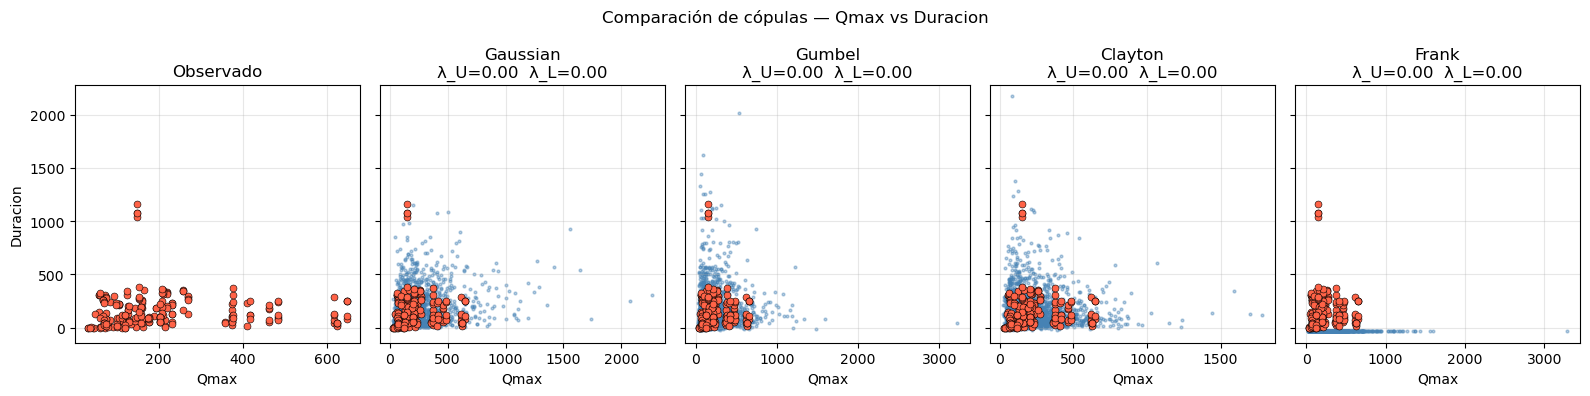


Familia recomendada para extremos: GAUSSIAN
Kendall τ medio: -0.101


In [10]:
from pyhydra.climate.hybrid_downscaling.event_selection import FloodCopulaComparison

# Usar las variables disponibles en eventos_obs o synthetic
_vars_avail = [c for c in ['Qmax', 'Qmed', 'Duracion'] if c in eventos_obs.columns]

if len(_vars_avail) == 3:
    print('Comparando familias de cópulas...')
    cop_cmp = FloodCopulaComparison(
        vars=_vars_avail,
        families=['gaussian', 'gumbel', 'clayton', 'frank']
    )
    cop_cmp.fit(eventos_obs[_vars_avail].dropna())

    tabla_copulas = cop_cmp.summary_table(n_samples=2000, seed=42)
    print('\n--- Tabla comparativa de cópulas ---')
    print(tabla_copulas.to_string(index=False))

    # Plot comparativo: Qmax vs Duracion para cada familia
    idx_pairs = (_vars_avail.index('Qmax'), _vars_avail.index('Duracion'))
    cop_cmp.plot_comparison(pair=idx_pairs, n_samples=2000, figsize=(16, 4))

    # Best family by upper tail dependence
    best_fam = cop_cmp.best_family(criterion='upper_tail')
    print(f'\nFamilia recomendada para extremos: {best_fam.upper()}')
    tau_pairs = cop_cmp._tau
    print(f'Kendall τ medio: {tau_pairs.get("mean", 0):.3f}')

else:
    print(f'Columnas disponibles en eventos_obs: {list(eventos_obs.columns)}')
    print('Necesarias: Qmax, Qmed, Duracion')

## 5. Representative selection — MaxDiss (Maximum Dissimilarity)

The **MaxDiss** algorithm iteratively selects the N most dissimilar synthetic events
(maximum dissimilarity in the normalised variable space). These N centroids are the
events simulated in HEC-RAS, covering the full variability of the possible event space.

```
1. Initialise with the event furthest from the mean
2. Each iteration: add the event with the greatest minimum distance to those already selected
3. Repeat until N=425 centroids are selected
```


In [11]:
hydro_files = sorted(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv'),
                     key=lambda f: int(f.stem.split('_')[1])) \
    if HYDRO_MAXDISS.exists() else []

if len(hydro_files) >= N_MAXDISS:
    # Cargar hidrogramas MaxDiss pre-computados
    print(f'Cargando {len(hydro_files)} hidrogramas MaxDiss pre-computados...')
    centroid_rows = []
    for hf in hydro_files:
        j = int(hf.stem.split('_')[1])
        try:
            df = pd.read_csv(hf, index_col=0)
            Q  = df.iloc[:, 0].values.astype(float)
            t  = df.index.astype(float)
            dur_h = (t[-1] - t[0]) / 3600.0 if len(t) > 1 else 0
            centroid_rows.append({
                'j': j,
                'Qmax':    round(float(np.max(Q)), 2),
                'Qmed':    round(float(np.mean(Q[Q > 0])) if np.any(Q > 0) else 0, 2),
                'Dur_h':   round(dur_h, 1),
            })
        except Exception as e:
            print(f'  Aviso: {hf.name} — {e}')

    centroids_df = pd.DataFrame(centroid_rows).set_index('j')
    print(f'Centroides cargados: {len(centroids_df)}')
    print(centroids_df.describe().round(1))

else:
    # Compute MaxDiss from the synthetic matrix
    print('Ejecutando HydrographReconstructor (MaxDiss + reconstrucción)...')
    print('(Puede tardar varios minutos dependiendo del número de eventos)')

    # Cargar hidrogramas observados
    HYDRO_OBS_DIR = PROC_DIR / 'hydrographs'
    obs_hydro_files = sorted(HYDRO_OBS_DIR.glob('Hidrograma_[0-9]*.csv'),
                              key=lambda f: int(f.stem.split('_')[1])) \
        if HYDRO_OBS_DIR.exists() else []

    obs_hydrographs = {}
    for hf in obs_hydro_files[:50]:  # máximo 50 para test
        j = int(hf.stem.split('_')[1])
        df = pd.read_csv(hf, index_col=0)
        obs_hydrographs[j] = df.iloc[:, 0]

    if obs_hydrographs and selector is not None:
        reconstructor = HydrographReconstructor(
            synthetic_events=synthetic,
            observed_hydrographs=obs_hydrographs,
            n_representatives=N_MAXDISS,
            output_dir=HYDRO_MAXDISS,
        )
        centroids_df, _ = reconstructor.build_hydrographs()
    else:
        print('⚠  Sin hidrogramas observados o selector no inicializado.')
        print('   Asegúrese de que processed/hydrographs/ contiene los hidrogramas.')
        centroids_df = pd.DataFrame()

Cargando 425 hidrogramas MaxDiss pre-computados...


Centroides cargados: 425
        Qmax   Qmed   Dur_h
count  425.0  425.0   425.0
mean   152.6   64.4   320.1
std     85.0   36.4   165.2
min     10.9    5.8    44.3
25%     84.3   36.7   206.8
50%    136.1   57.9   286.9
75%    203.7   81.8   417.0
max    452.1  231.3  1090.9


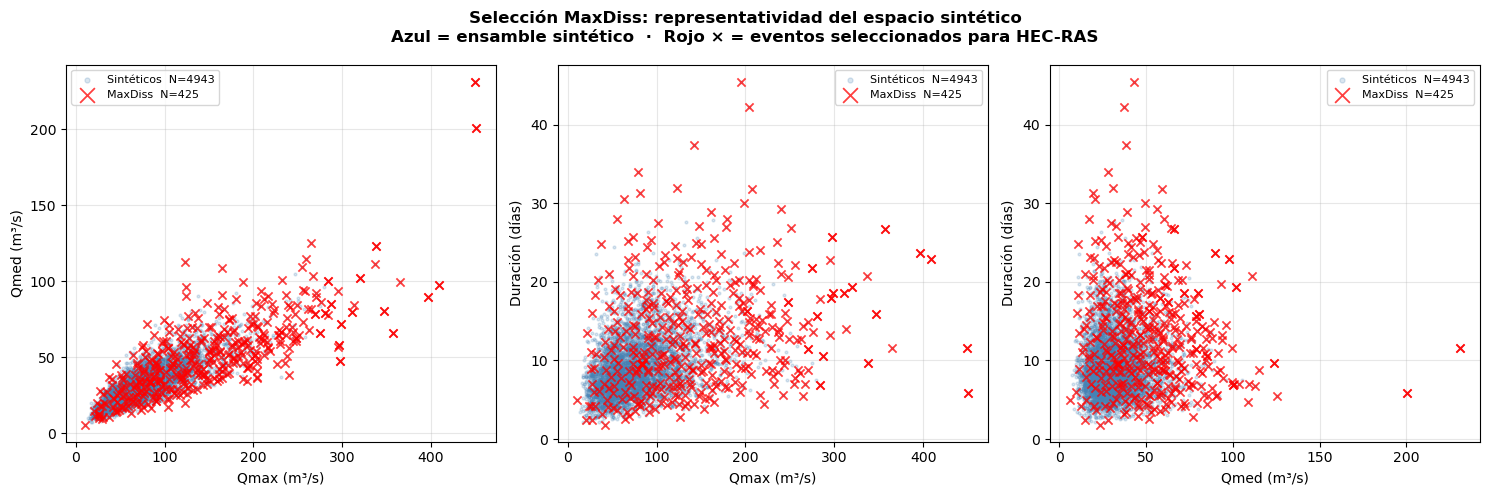

In [12]:
# --- Plot 3c: MaxDiss selection — 3-panel scatter ---
# Blue dots = full synthetic ensemble
# Red × = N_MAXDISS events selected by MaxDiss algorithm
_md_src = None
if EVENTOS_MAXDISS.exists():
    _md_src = pd.read_csv(EVENTOS_MAXDISS, index_col=0)
elif 'eventos_maxdiss' in dir() and not eventos_maxdiss.empty:
    _md_src = eventos_maxdiss

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_pairs = [
    ('Qmax',    'Qmed',    'Qmax (m³/s)',    'Qmed (m³/s)'),
    ('Qmax',    'Duracion','Qmax (m³/s)',    'Duración (días)'),
    ('Qmed',    'Duracion','Qmed (m³/s)',    'Duración (días)'),
]
for ax, (cx, cy, lx, ly) in zip(axes, _pairs):
    if cx in synthetic.columns and cy in synthetic.columns:
        ax.scatter(synthetic[cx], synthetic[cy],
                   s=4, alpha=0.2, color='steelblue',
                   label=f'Sintéticos  N={len(synthetic)}')
    if _md_src is not None and cx in _md_src.columns and cy in _md_src.columns:
        ax.scatter(_md_src[cx], _md_src[cy],
                   s=35, alpha=0.75, color='red', marker='x', lw=1.3, zorder=5,
                   label=f'MaxDiss  N={len(_md_src)}')
    ax.set(xlabel=lx, ylabel=ly)
    ax.legend(fontsize=8, markerscale=1.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Selección MaxDiss: representatividad del espacio sintético\n'
             'Azul = ensamble sintético  ·  Rojo × = eventos seleccionados para HEC-RAS',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'scatter_maxdiss_selection.png', dpi=150, bbox_inches='tight')
plt.show()
if _md_src is None:
    print('⚠  eventos_maxdiss.csv no disponible — ejecutar HydrographReconstructor primero')

## 6. MaxDiss hydrograph visualisation

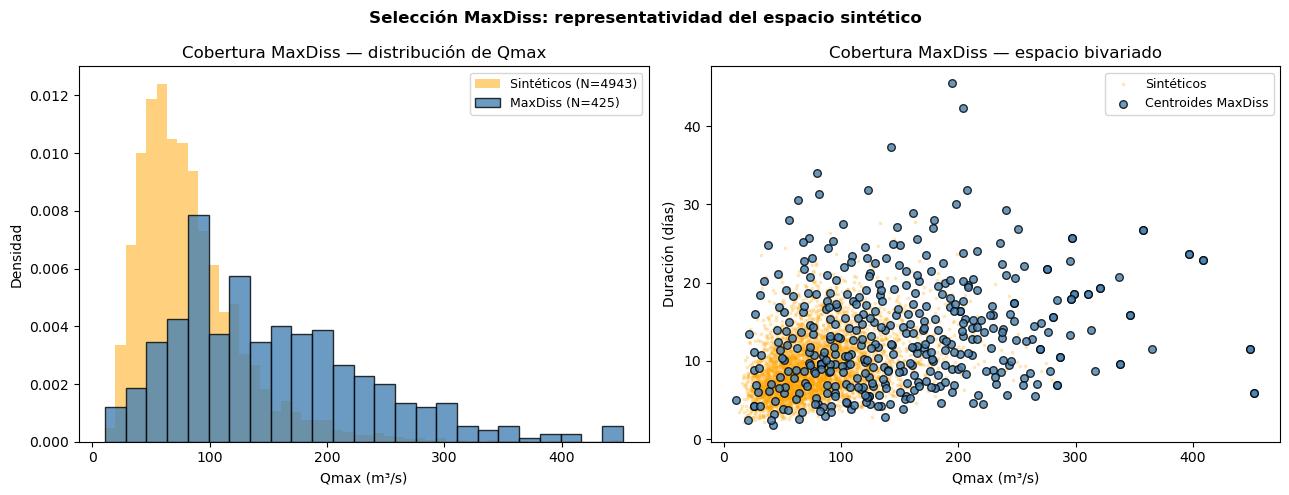

In [13]:
# Qmax distribution: MaxDiss centroids vs full synthetic ensemble
if not centroids_df.empty and 'Qmax' in centroids_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histograma comparativo
    ax = axes[0]
    if 'Qmax' in synthetic.columns:
        ax.hist(synthetic['Qmax'], bins=50, density=True, alpha=0.5,
                color='orange', label=f'Sintéticos (N={len(synthetic)})', edgecolor='none')
    ax.hist(centroids_df['Qmax'], bins=25, density=True, alpha=0.8,
            color='steelblue', label=f'MaxDiss (N={len(centroids_df)})', edgecolor='k')
    ax.set(xlabel='Qmax (m³/s)', ylabel='Densidad',
           title='Cobertura MaxDiss — distribución de Qmax')
    ax.legend(fontsize=9)

    # Scatter: Qmax vs Duration
    ax = axes[1]
    if 'Qmax' in synthetic.columns and 'Duracion' in synthetic.columns:
        ax.scatter(synthetic['Qmax'], synthetic['Duracion'],
                   s=3, alpha=0.2, color='orange', label='Sintéticos')
    ax.scatter(centroids_df['Qmax'], centroids_df['Dur_h'] / 24.0,
               s=30, alpha=0.8, color='steelblue', edgecolors='k', zorder=5,
               label='Centroides MaxDiss')
    ax.set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
           title='Cobertura MaxDiss — espacio bivariado')
    ax.legend(fontsize=9)

    plt.suptitle('Selección MaxDiss: representatividad del espacio sintético',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'maxdiss_coverage.png', dpi=150)
    plt.show()

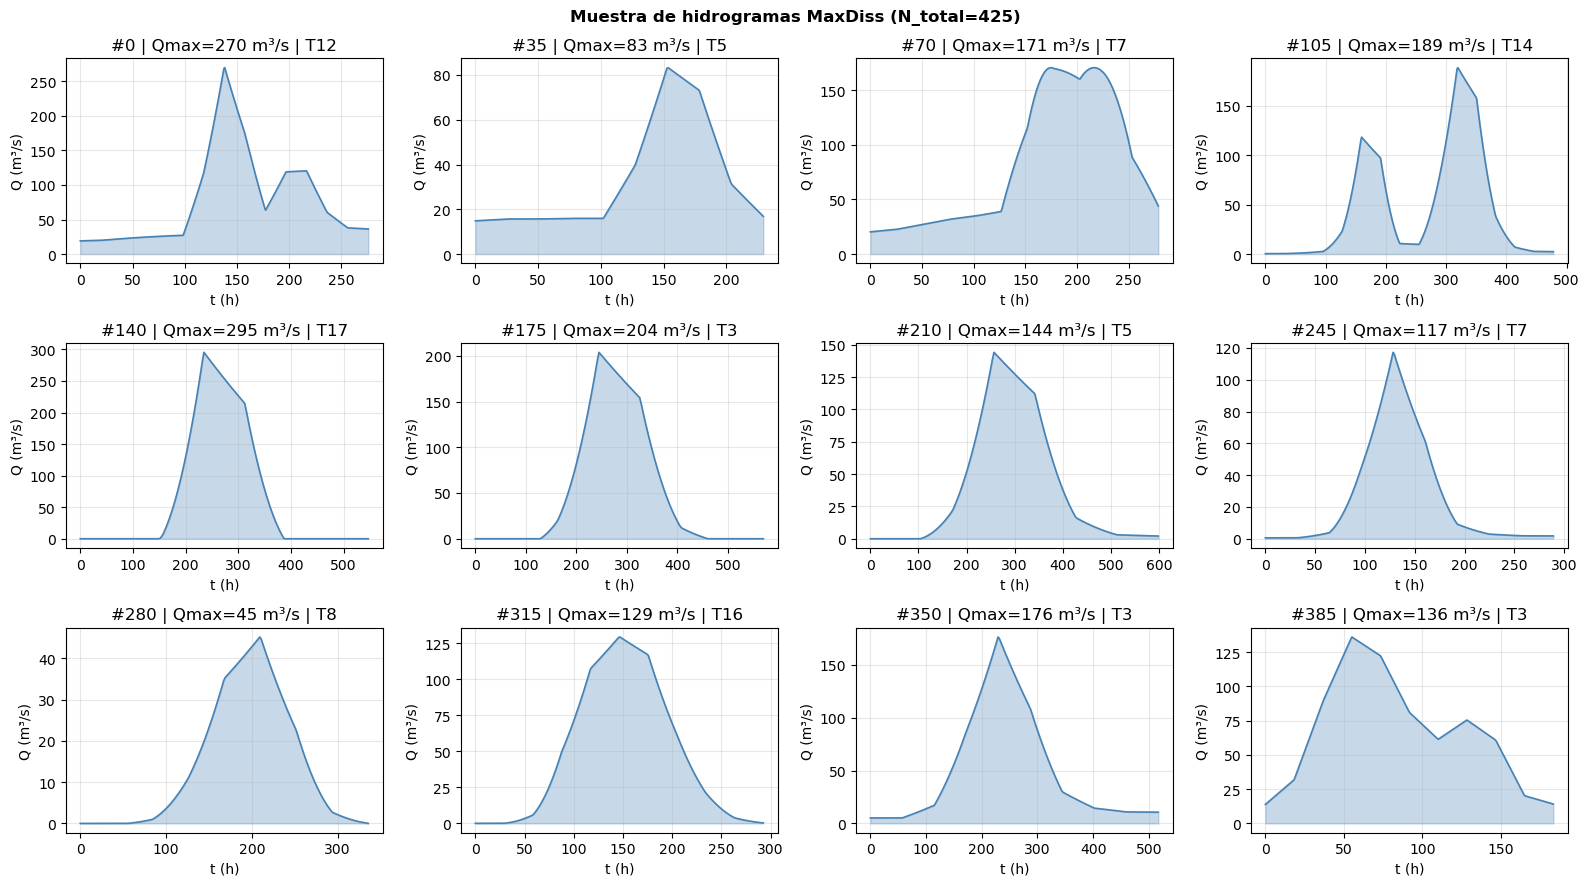

In [14]:
# Muestra de hidrogramas MaxDiss: 12 ejemplos representativos
if HYDRO_MAXDISS.exists():
    sample_files = hydro_files[::max(1, len(hydro_files) // 12)][:12]

    # Get hydrograph type if available
    tipo_map = {}
    if 'Tipo_Hidro' in synthetic.columns and 'Qmax' in synthetic.columns:
        for idx_row, row in synthetic.iterrows():
            tipo_map[idx_row] = row['Tipo_Hidro']

    colors_t = {0: 'steelblue', 1: 'darkorange', 2: 'forestgreen'}

    fig, axes = plt.subplots(3, 4, figsize=(16, 9))
    axes = axes.ravel()

    for ax, hf in zip(axes, sample_files):
        try:
            j = int(hf.stem.split('_')[1])
            df = pd.read_csv(hf, index_col=0)
            t  = df.index.astype(float) / 3600.0  # segundos → horas
            Q  = df.iloc[:, 0].values.astype(float)
            tipo = tipo_map.get(j, 0)
            c    = colors_t.get(int(tipo) if pd.notna(tipo) else 0, 'steelblue')
            ax.fill_between(t, Q, alpha=0.3, color=c)
            ax.plot(t, Q, lw=1.2, color=c)
            ax.set(title=f'#{j} | Qmax={Q.max():.0f} m³/s | T{int(tipo)}',
                   xlabel='t (h)', ylabel='Q (m³/s)')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.set_title(f'Error: {e}')

    plt.suptitle(f'Muestra de hidrogramas MaxDiss (N_total={len(hydro_files)})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'maxdiss_sample_hydros.png', dpi=150)
    plt.show()

## 6b. Flood map reconstruction method comparison

The hybrid methodology reconstructs flood inundation maps for synthetic events by
interpolating between HEC-RAS simulated centroids. This is methodologically valid
only when the centroid maps span the event space. In the release dataset, some
rasters may be reduced reference maps rather than a full 425-member hydraulic
simulation library, so the section is treated as an API/workflow check unless the
full `Simul_j.tif` collection is present.

Two methods are implemented in `FloodMapInterpolator`:

| Method | Description | Parameters |
|--------|-------------|------------|
| **KNN** (K-nearest neighbours) | Inverse-distance weighted average of the **k** nearest centroids | k=6 |
| **RBF** (Radial Basis Functions) | Gaussian kernel weighted average over **all** centroids | σ=auto |

**KNN** is local; **RBF** is smoother and more global. Both require hydraulic
support points that cover the target event range.


Evento de diseño T=100: Qmax=308 m³/s  Qmed=169 m³/s  Dur=12.0 días

KNN (k=6): índices seleccionados: [ 68 143  13 140   4 170]
  pesos: [0.1824 0.1703 0.1536 0.1577 0.1824 0.1536]  (suma=1.0000)

RBF: top-5 centroides con mayor peso:
  centroide #4: Qmax=298  w=0.0129
  centroide #68: Qmax=298  w=0.0129
  centroide #143: Qmax=313  w=0.0129
  centroide #140: Qmax=295  w=0.0128
  centroide #170: Qmax=287  w=0.0128


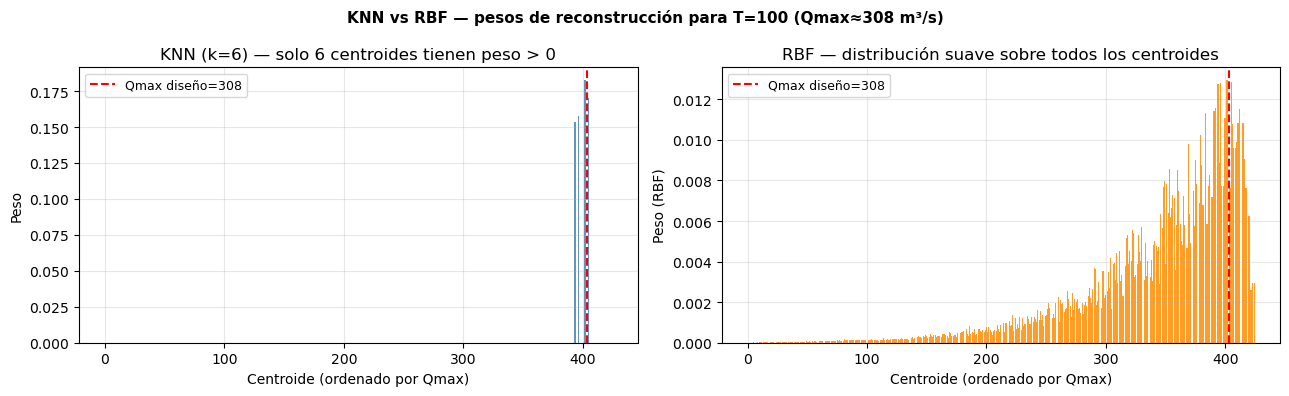


--- FloodMapInterpolator API ---
method="knn" → FloodMapInterpolator(..., method="knn", k_neighbors=6)
method="rbf" → FloodMapInterpolator(..., method="rbf", rbf_sigma=None)

⚠  /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/flood_maps/simulations no existe — la reconstrucción requiere Simul_j.tif de HEC-RAS


In [15]:
# hydro_metHab is populated in Section 7 below; use empty dict as default here
_hydro_mh = hydro_metHab if 'hydro_metHab' in dir() else {}

from pyhydra.climate.hybrid_downscaling.interpolation import _knn_weights, _rbf_weights
from pyhydra.climate.hybrid_downscaling import FloodMapInterpolator

# Compare KNN vs RBF weights for a test design event
if not centroids_df.empty and 'Qmax' in centroids_df.columns:

    # Construir feature matrix de centroides con columnas disponibles
    centroid_feat = pd.DataFrame({
        'Qmax':    centroids_df['Qmax'].values,
        'Qmed':    centroids_df.get('Qmed', centroids_df['Qmax'] * 0.55).values,
        'Duracion':centroids_df.get('Dur_h', centroids_df.get('Duracion', 48.0)).values / 24.0,
    }, index=centroids_df.index)

    # T=100 design event
    q_ref = _hydro_mh[100].max() if 100 in _hydro_mh else float(centroids_df['Qmax'].quantile(0.95))
    design_event = pd.DataFrame({
        'Qmax':    [q_ref],
        'Qmed':    [q_ref * 0.55],
        'Duracion':[centroid_feat['Duracion'].median()],
    })
    print(f'Evento de diseño T=100: Qmax={q_ref:.0f} m³/s  '
          f'Qmed={q_ref*0.55:.0f} m³/s  Dur={centroid_feat["Duracion"].median():.1f} días')

    k = min(6, len(centroid_feat) - 1)
    knn_pos, knn_w = _knn_weights(design_event, centroid_feat, k=k)  # (positions, weights)
    rbf_w          = _rbf_weights(design_event, centroid_feat)

    # Expandir pesos KNN a vector completo (cero para centroides no seleccionados)
    full_knn = np.zeros(len(centroid_feat))
    for idx, w in zip(knn_pos[0], knn_w[0]):
        full_knn[idx] = w

    print(f'\nKNN (k={k}): índices seleccionados: {knn_pos[0]}')
    print(f'  pesos: {knn_w[0].round(4)}  (suma={knn_w[0].sum():.4f})')
    print(f'\nRBF: top-5 centroides con mayor peso:')
    for idx in np.argsort(-rbf_w[0])[:5]:
        print(f'  centroide #{centroid_feat.index[idx]}: '
              f'Qmax={centroid_feat.iloc[idx]["Qmax"]:.0f}  w={rbf_w[0,idx]:.4f}')

    # Visualisation
    x_axis = np.arange(len(centroid_feat))
    sort_order = np.argsort(centroid_feat['Qmax'].values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.bar(range(len(centroid_feat)), full_knn[sort_order], color='steelblue', alpha=0.85)
    ax.axvline(np.searchsorted(centroid_feat['Qmax'].values[sort_order], q_ref),
               color='red', lw=1.5, ls='--', label=f'Qmax diseño={q_ref:.0f}')
    ax.set(xlabel='Centroide (ordenado por Qmax)', ylabel='Peso',
           title=f'KNN (k={k}) — solo {k} centroides tienen peso > 0')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(range(len(centroid_feat)), rbf_w[0, sort_order], color='darkorange', alpha=0.85)
    ax.axvline(np.searchsorted(centroid_feat['Qmax'].values[sort_order], q_ref),
               color='red', lw=1.5, ls='--', label=f'Qmax diseño={q_ref:.0f}')
    ax.set(xlabel='Centroide (ordenado por Qmax)', ylabel='Peso (RBF)',
           title='RBF — distribución suave sobre todos los centroides')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'KNN vs RBF — pesos de reconstrucción para T=100 (Qmax≈{q_ref:.0f} m³/s)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'reconstruction_weights_comparison.png', dpi=150)
    plt.show()

    # Example API call using RBF method
    SIM_DIR = PROC_DIR / 'flood_maps' / 'simulations'
    print(f'\n--- FloodMapInterpolator API ---')
    print(f'method="knn" → FloodMapInterpolator(..., method="knn", k_neighbors=6)')
    print(f'method="rbf" → FloodMapInterpolator(..., method="rbf", rbf_sigma=None)')
    if not SIM_DIR.exists():
        print(f'\n⚠  {SIM_DIR} no existe — la reconstrucción requiere Simul_j.tif de HEC-RAS')

else:
    print('centroids_df vacío — saltando comparación de métodos de reconstrucción.')

## 7. T-year hydrographs for HEC-RAS (Met-Hab)

The hybrid method also generates design hydrographs for standard return periods
using the reconstruction results. These hydrographs (Met-Hab) are used as input
to the hydraulic model HEC-RAS in **Notebook 07**.


Hidrogramas Met-Hab disponibles: [2, 5, 10, 25, 50, 100, 200, 500]


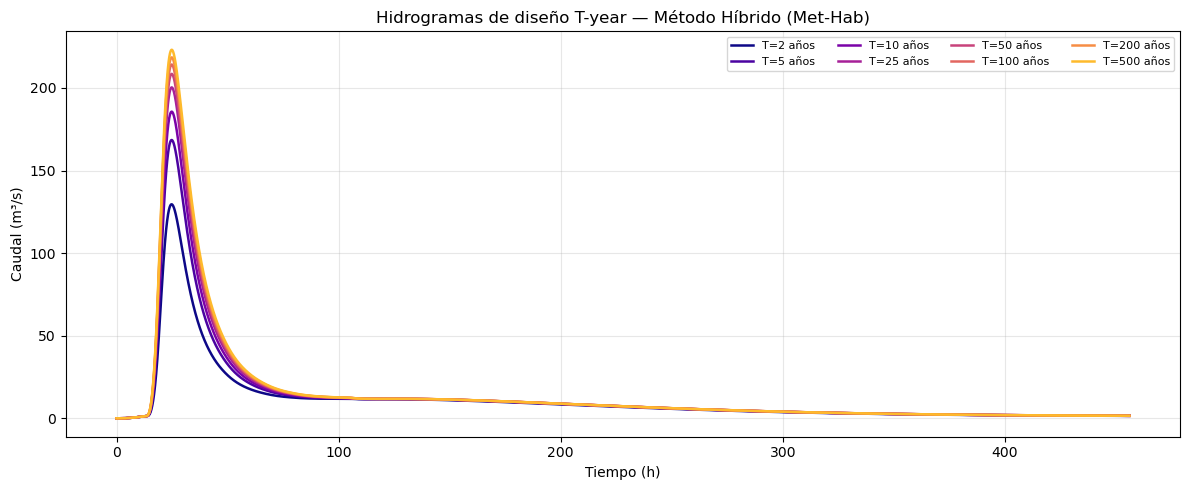


Caudales pico Met-Hab:
 T_years  Qmax_m3s  Dur_h
       2 129.55038  456.0
       5 168.46187  456.0
      10 185.63127  456.0
      25 200.31323  456.0
      50 208.48242  456.0
     100 214.17767  456.0
     200 218.49515  456.0
     500 223.09412  456.0


In [16]:
MET_HAB_DIR = HYDRO_MAXDISS / 'Met_Hab'
hydro_metHab = {}

if MET_HAB_DIR.exists():
    for T in RETURN_PERIODS:
        hf = MET_HAB_DIR / f'Hidrograma_T{T}.csv'
        if hf.exists():
            df = pd.read_csv(hf, index_col=0)
            s  = df.iloc[:, 0].astype(float)
            t_h = s.index.astype(float) / 3600.0  # s → h
            hydro_metHab[T] = pd.Series(s.values, index=t_h, name=f'T{T}')

print(f'Hidrogramas Met-Hab disponibles: {list(hydro_metHab.keys())}')

if hydro_metHab:
    colors_T = plt.cm.plasma(np.linspace(0, 0.85, len(hydro_metHab)))
    fig, ax = plt.subplots(figsize=(12, 5))
    for (T, h), c in zip(hydro_metHab.items(), colors_T):
        ax.plot(h.index, h.values, lw=1.8, color=c, label=f'T={T} años')
    ax.set(xlabel='Tiempo (h)', ylabel='Caudal (m³/s)',
           title='Hidrogramas de diseño T-year — Método Híbrido (Met-Hab)')
    ax.legend(ncol=4, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'hidrogramas_metHab_Tyear.png', dpi=150)
    plt.show()

    # Tabla de caudales pico
    peak_table = pd.DataFrame({
        'T_years': list(hydro_metHab.keys()),
        'Qmax_m3s': [h.max() for h in hydro_metHab.values()],
        'Dur_h':    [h.index[-1] - h.index[0] for h in hydro_metHab.values()],
    })
    print('\nCaudales pico Met-Hab:')
    print(peak_table.to_string(index=False))
else:
    print('⚠  No se encontraron hidrogramas Met-Hab en:', MET_HAB_DIR)
    print('   Estos se generan en el post-procesado de la reconstrucción.')

## 8. Summary and preparation for HEC-RAS

Outputs from this notebook used in **Notebook 07 (HEC-RAS)**:

| File | Use in NB07 |
|---|---|
| `hydrographs_maxdiss/Hidrograma_*.csv` | 425 hydrographs for HEC-RAS simulation |
| `hydrographs_maxdiss/Met_Hab/Hidrograma_T*.csv` | T-year hydrographs for validation |
| `matriz_sintetica_maxdiss.csv` | Event metadata (Qmax, type, …) |
| `eventos_maxdiss.csv` | MaxDiss-selected events |


In [17]:
print('=' * 55)
print('RESUMEN — Notebook 06')
print('=' * 55)

n_obs_events = len(eventos_obs) if 'eventos_obs' in dir() else '—'
n_synth      = len(synthetic)   if 'synthetic' in dir()   else '—'
n_maxdiss_h  = len(hydro_files) if 'hydro_files' in dir() else '—'
n_metHab     = len(hydro_metHab)

print(f'  Eventos observados          : {n_obs_events}')
print(f'  Eventos sintéticos (cópula) : {n_synth}')
print(f'  Hidrogramas MaxDiss         : {n_maxdiss_h}')
print(f'  Hidrogramas T-year Met-Hab  : {n_metHab}')

met_hab_available = MET_HAB_DIR.exists() and n_metHab > 0
maxdiss_available = len(hydro_files) >= N_MAXDISS if 'hydro_files' in dir() else False

print()
print(f'  [{ "OK" if maxdiss_available else "!!" }] Hidrogramas MaxDiss listos para HEC-RAS')
print(f'  [{ "OK" if met_hab_available else "!!" }] Hidrogramas Met-Hab listos para HEC-RAS')
print()
print('→ Continuar en Notebook 07: 07_hec_ras_hydraulics.ipynb')
print('=' * 55)

RESUMEN — Notebook 06
  Eventos observados          : 224
  Eventos sintéticos (cópula) : 4943
  Hidrogramas MaxDiss         : 425
  Hidrogramas T-year Met-Hab  : 8

  [OK] Hidrogramas MaxDiss listos para HEC-RAS
  [OK] Hidrogramas Met-Hab listos para HEC-RAS

→ Continuar en Notebook 07: 07_hec_ras_hydraulics.ipynb
